In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import torch.optim as optim

Using cache found in /home/sarafrz/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Middle layer (Conv)
Layer name: layer2.0.conv1
Original shape: (32, 16, 3, 3)
2D shape: (32, 144)
Max rank: 32
k95: 24
Percent of rank: 75.0

Final layer (Linear)
Layer name: fc
Original shape: (10, 64)
2D shape: (10, 64)
Max rank: 10
k95: 9
Percent of rank: 90.0


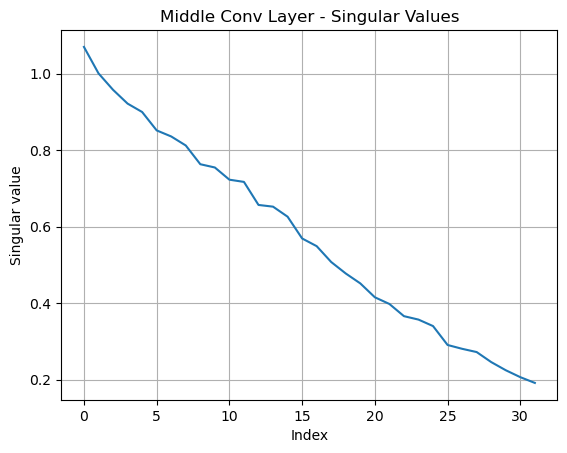

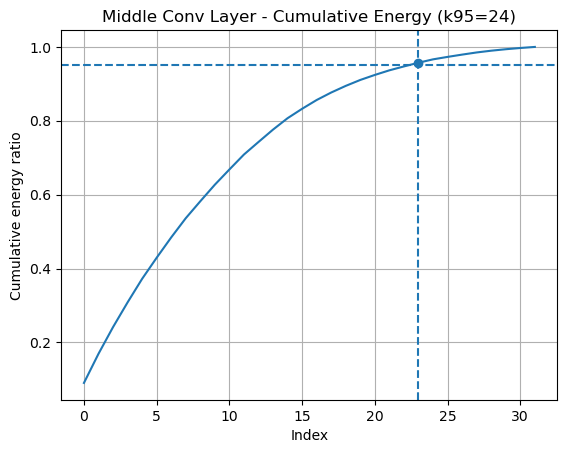

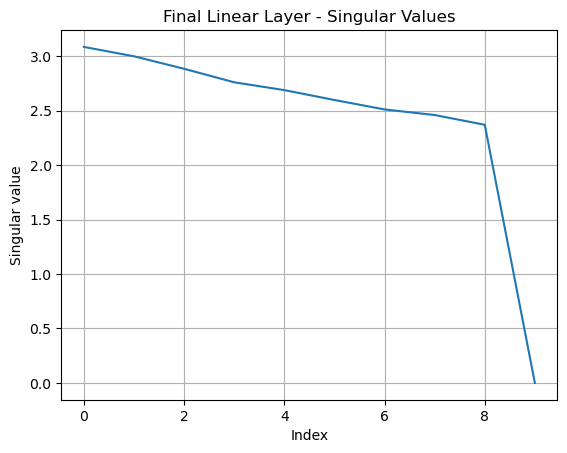

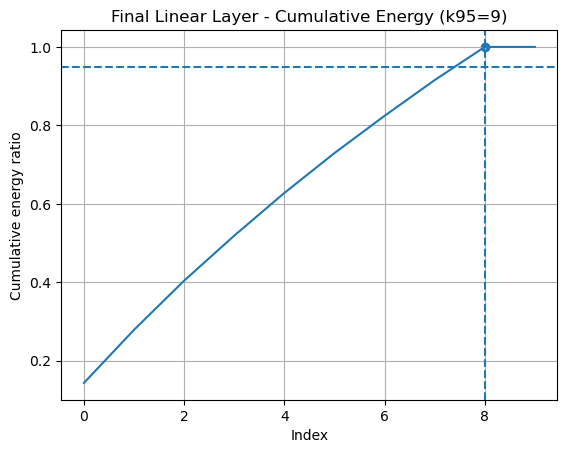

In [ ]:
model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
)
model.eval()

def weight_to_2d(W):
    if W.ndim == 4:
        o, i, h, w = W.shape
        return W.reshape(o, i * h * w)
    if W.ndim == 2:
        return W
    raise ValueError(W.shape)

def sv_spectrum_and_k95(W2d, threshold=0.95):
    s = np.linalg.svd(W2d, compute_uv=False)
    energy = s ** 2
    ratio = np.cumsum(energy) / np.sum(energy)
    k = int(np.searchsorted(ratio, threshold) + 1)
    return s, ratio, k

def plot_spectrum_and_ratio(s, ratio, k, title):
    plt.figure()
    plt.plot(s)
    plt.title(title + " - Singular Values")
    plt.xlabel("Index")
    plt.ylabel("Singular value")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(ratio)
    plt.axhline(0.95, linestyle="--")
    plt.axvline(k - 1, linestyle="--")
    plt.scatter([k - 1], [ratio[k - 1]])
    plt.title(title + f" - Cumulative Energy (k95={k})")
    plt.xlabel("Index")
    plt.ylabel("Cumulative energy ratio")
    plt.grid(True)
    plt.show()

modules = dict(model.named_modules())

conv_candidates = [
    "layer2.0.conv1",
    "layer2.0.conv2",
    "layer2.1.conv1",
    "layer2.1.conv2",
]

mid_conv_name = None
for c in conv_candidates:
    if c in modules and isinstance(modules[c], torch.nn.Conv2d):
        mid_conv_name = c
        break

if mid_conv_name is None:
    conv_names = [n for n, m in modules.items() if isinstance(m, torch.nn.Conv2d)]
    mid_conv_name = conv_names[len(conv_names) // 2]

linear_names = [n for n, m in modules.items() if isinstance(m, torch.nn.Linear)]
final_linear_name = linear_names[-1]

mid_conv_layer = modules[mid_conv_name]
final_linear_layer = modules[final_linear_name]

W_mid = mid_conv_layer.weight.detach().cpu().numpy()
W_fc = final_linear_layer.weight.detach().cpu().numpy()

W_mid_2d = weight_to_2d(W_mid)
W_fc_2d = weight_to_2d(W_fc)

s_mid, ratio_mid, k95_mid = sv_spectrum_and_k95(W_mid_2d)
s_fc, ratio_fc, k95_fc = sv_spectrum_and_k95(W_fc_2d)

print("Middle layer (Conv)")
print("Layer name:", mid_conv_name)
print("Original shape:", W_mid.shape)
print("2D shape:", W_mid_2d.shape)
print("Max rank:", min(W_mid_2d.shape))
print("k95:", k95_mid)
print("Percent of rank:", 100 * k95_mid / min(W_mid_2d.shape))

print("\nFinal layer (Linear)")
print("Layer name:", final_linear_name)
print("Original shape:", W_fc.shape)
print("2D shape:", W_fc_2d.shape)
print("Max rank:", min(W_fc_2d.shape))
print("k95:", k95_fc)
print("Percent of rank:", 100 * k95_fc / min(W_fc_2d.shape))

plot_spectrum_and_ratio(s_mid, ratio_mid, k95_mid, "Middle Conv Layer")
plot_spectrum_and_ratio(s_fc, ratio_fc, k95_fc, "Final Linear Layer")


In [3]:
#part 2
def get_cifar10_test_loader(batch_size=256, num_workers=2):
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])
    test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
    return DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

@torch.no_grad()
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

def count_params(module):
    return sum(p.numel() for p in module.parameters())

def linear_param_count(m, n, has_bias=True):
    return m * n + (m if has_bias else 0)

def factorized_linear_param_count(m, n, k, has_bias=True):
    first = k * n
    second = m * k
    bias = m if has_bias else 0
    return first + second + bias

def choose_k_nearest_reduction(m, n, reduction_ratio, has_bias=True):
    original = linear_param_count(m, n, has_bias=has_bias)
    target = int(round((1.0 - reduction_ratio) * original))
    kmax = min(m, n)
    best_k = 1
    best_diff = None
    for k in range(1, kmax + 1):
        newp = factorized_linear_param_count(m, n, k, has_bias=has_bias)
        diff = abs(newp - target)
        if best_diff is None or diff < best_diff:
            best_diff = diff
            best_k = k
    return best_k

def compress_linear_svd(linear_layer, k):
    if not isinstance(linear_layer, nn.Linear):
        raise TypeError(type(linear_layer))

    W = linear_layer.weight.detach()
    b = linear_layer.bias.detach() if linear_layer.bias is not None else None

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    k = min(k, S.numel())

    U_k = U[:, :k]
    S_k = S[:k]
    Vh_k = Vh[:k, :]

    first = nn.Linear(linear_layer.in_features, k, bias=False)
    second = nn.Linear(k, linear_layer.out_features, bias=True)

    first.weight.data.copy_(Vh_k)
    second.weight.data.copy_(U_k * S_k.unsqueeze(0))

    if b is not None:
        second.bias.data.copy_(b)
    else:
        second.bias.data.zero_()

    return nn.Sequential(first, second)

def pct_reduction(new_val, old_val):
    return 100.0 * (1.0 - (new_val / old_val))

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    test_loader = get_cifar10_test_loader()

    model_base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    model_base.eval()

    model_50 = copy.deepcopy(model_base)
    model_80 = copy.deepcopy(model_base)

    if not isinstance(model_base.fc, nn.Linear):
        raise RuntimeError("Expected model.fc to be nn.Linear")

    m = model_base.fc.out_features
    n = model_base.fc.in_features
    has_bias = model_base.fc.bias is not None

    k50 = choose_k_nearest_reduction(m, n, reduction_ratio=0.50, has_bias=has_bias)
    k80 = choose_k_nearest_reduction(m, n, reduction_ratio=0.80, has_bias=has_bias)

    model_50.fc = compress_linear_svd(model_50.fc, k50)
    model_80.fc = compress_linear_svd(model_80.fc, k80)

    model_base = model_base.to(device)
    model_50 = model_50.to(device)
    model_80 = model_80.to(device)

    acc_base = evaluate_accuracy(model_base, test_loader, device)
    acc_50 = evaluate_accuracy(model_50, test_loader, device)
    acc_80 = evaluate_accuracy(model_80, test_loader, device)

    total_base = count_params(model_base)
    total_50 = count_params(model_50)
    total_80 = count_params(model_80)

    fc_base = count_params(model_base.fc)
    fc_50 = count_params(model_50.fc)
    fc_80 = count_params(model_80.fc)

    print("Part 2 Results (CIFAR-10 pretrained / Initial)")
    print(f"Baseline accuracy: {acc_base:.2f}%")
    print(f"50% compression (fc k={k50}) accuracy: {acc_50:.2f}%")
    print(f"80% compression (fc k={k80}) accuracy: {acc_80:.2f}%")

    print("\nParameter Comparison Table")
    print("Variant        | Total Params | Total Red. | FC Params | FC Red.")
    print("-" * 72)
    print(f"Baseline       | {total_base:,} | {0.00:9.2f}% | {fc_base:,} | {0.00:7.2f}%")
    print(f"50% (k={k50})  | {total_50:,} | {pct_reduction(total_50, total_base):9.2f}% | {fc_50:,} | {pct_reduction(fc_50, fc_base):7.2f}%")
    print(f"80% (k={k80})  | {total_80:,} | {pct_reduction(total_80, total_base):9.2f}% | {fc_80:,} | {pct_reduction(fc_80, fc_base):7.2f}%")

    print("\nFC Layer Details")
    print(f"Original fc: out={m}, in={n}, bias={has_bias}")
    print(f"Chosen k50={k50}, chosen k80={k80}")
    print(f"Original fc params: {fc_base:,}")
    print(f"New fc params (50%): {fc_50:,}")
    print(f"New fc params (80%): {fc_80:,}")

if __name__ == "__main__":
    main()


Files already downloaded and verified


Using cache found in /home/sarafrz/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Part 2 Results (CIFAR-10 pretrained / Initial)
Baseline accuracy: 92.12%
50% compression (fc k=4) accuracy: 76.90%
80% compression (fc k=2) accuracy: 37.88%

Parameter Comparison Table
Variant        | Total Params | Total Red. | FC Params | FC Red.
------------------------------------------------------------------------
Baseline       | 272,474 |      0.00% | 650 |    0.00%
50% (k=4)  | 272,130 |      0.13% | 306 |   52.92%
80% (k=2)  | 271,982 |      0.18% | 158 |   75.69%

FC Layer Details
Original fc: out=10, in=64, bias=True
Chosen k50=4, chosen k80=2
Original fc params: 650
New fc params (50%): 306
New fc params (80%): 158


Files already downloaded and verified
Files already downloaded and verified


Using cache found in /home/sarafrz/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Before fine-tuning
Baseline acc: 92.12%
50% target (k=4) acc: 76.90%
80% target (k=2) acc: 37.88%
FC compression rates: 0.00%, 52.92%, 75.69%
Total compression rates: 0.0000%, 0.1263%, 0.1806%

Epoch 1/3
Baseline: loss=0.0124, acc=92.48%
Compressed 50: loss=0.0907, acc=90.53%
Compressed 80: loss=0.5834, acc=75.40%

Epoch 2/3
Baseline: loss=0.0120, acc=92.50%
Compressed 50: loss=0.0500, acc=90.64%
Compressed 80: loss=0.4383, acc=75.48%

Epoch 3/3
Baseline: loss=0.0105, acc=92.53%
Compressed 50: loss=0.0470, acc=90.57%
Compressed 80: loss=0.4089, acc=78.08%

CPU inference latency
Baseline: 367.85 ± 63.95 ms/batch | 1.4644 ± 0.2546 ms/image
Compressed 50: 309.72 ± 46.63 ms/batch | 1.2330 ± 0.1856 ms/image
Compressed 80: 302.15 ± 41.26 ms/batch | 1.2028 ± 0.1643 ms/image


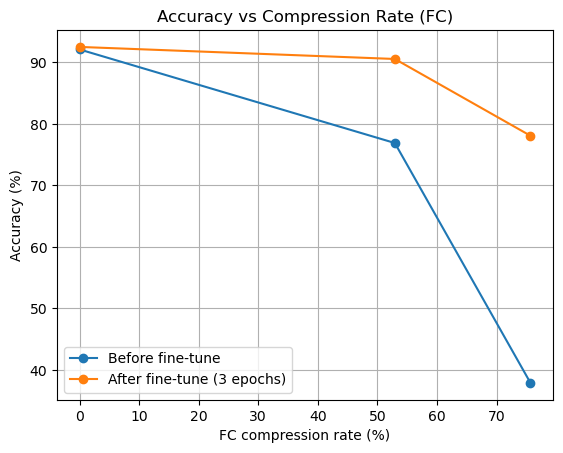

In [5]:
#part 3
def get_cifar10_loaders(batch_size=256, num_workers=2):
    tfm_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                             std=(0.2470, 0.2435, 0.2616)),
    ])
    train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm_train)
    test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm_test)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

@torch.no_grad()
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(dataloader.dataset)

def count_params(module):
    return sum(p.numel() for p in module.parameters())

def linear_param_count(m, n, has_bias=True):
    return m * n + (m if has_bias else 0)

def factorized_linear_param_count(m, n, k, has_bias=True):
    return k * n + m * k + (m if has_bias else 0)

def choose_k_nearest_reduction(m, n, reduction_ratio, has_bias=True):
    original = linear_param_count(m, n, has_bias=has_bias)
    target = int(round((1.0 - reduction_ratio) * original))
    kmax = min(m, n)
    best_k = 1
    best_diff = None
    for k in range(1, kmax + 1):
        newp = factorized_linear_param_count(m, n, k, has_bias=has_bias)
        diff = abs(newp - target)
        if best_diff is None or diff < best_diff:
            best_diff = diff
            best_k = k
    return best_k

def compress_linear_svd(linear_layer, k):
    if not isinstance(linear_layer, nn.Linear):
        raise TypeError(type(linear_layer))

    W = linear_layer.weight.detach()
    b = linear_layer.bias.detach() if linear_layer.bias is not None else None

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)
    k = min(k, S.numel())

    U_k = U[:, :k]
    S_k = S[:k]
    Vh_k = Vh[:k, :]

    first = nn.Linear(linear_layer.in_features, k, bias=False)
    second = nn.Linear(k, linear_layer.out_features, bias=True)

    first.weight.data.copy_(Vh_k)
    second.weight.data.copy_(U_k * S_k.unsqueeze(0))

    if b is not None:
        second.bias.data.copy_(b)
    else:
        second.bias.data.zero_()

    return nn.Sequential(first, second)

@torch.no_grad()
def measure_cpu_latency(model, dataloader, num_batches=50, warmup=10):
    model_cpu = copy.deepcopy(model).to("cpu")
    model_cpu.eval()

    w = 0
    for x, _ in dataloader:
        _ = model_cpu(x)
        w += 1
        if w >= warmup:
            break

    times = []
    sizes = []
    while len(times) < num_batches:
        for x, _ in dataloader:
            t0 = time.perf_counter()
            _ = model_cpu(x)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000.0)
            sizes.append(x.size(0))
            if len(times) >= num_batches:
                break

    mean_ms_batch = float(np.mean(times))
    std_ms_batch = float(np.std(times))
    mean_bs = float(np.mean(sizes))
    mean_ms_img = mean_ms_batch / mean_bs
    std_ms_img = std_ms_batch / mean_bs
    return mean_ms_batch, std_ms_batch, mean_ms_img, std_ms_img

def pct_reduction(new_val, old_val):
    return 100.0 * (1.0 - (new_val / old_val))

def freeze_all_but_fc(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_loader, test_loader = get_cifar10_loaders(batch_size=256)

    model_base = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    if not isinstance(model_base.fc, nn.Linear):
        raise RuntimeError("Expected model.fc to be nn.Linear")

    model_50 = copy.deepcopy(model_base)
    model_80 = copy.deepcopy(model_base)

    m = model_base.fc.out_features
    n = model_base.fc.in_features
    has_bias = model_base.fc.bias is not None

    k50 = choose_k_nearest_reduction(m, n, reduction_ratio=0.50, has_bias=has_bias)
    k80 = choose_k_nearest_reduction(m, n, reduction_ratio=0.80, has_bias=has_bias)

    model_50.fc = compress_linear_svd(model_50.fc, k50)
    model_80.fc = compress_linear_svd(model_80.fc, k80)

    freeze_all_but_fc(model_base)
    freeze_all_but_fc(model_50)
    freeze_all_but_fc(model_80)

    model_base = model_base.to(device)
    model_50 = model_50.to(device)
    model_80 = model_80.to(device)

    acc_base_0 = evaluate_accuracy(model_base, test_loader, device)
    acc_50_0 = evaluate_accuracy(model_50, test_loader, device)
    acc_80_0 = evaluate_accuracy(model_80, test_loader, device)

    total_base_0 = count_params(model_base)
    total_50_0 = count_params(model_50)
    total_80_0 = count_params(model_80)

    fc_base_0 = count_params(model_base.fc)
    fc_50_0 = count_params(model_50.fc)
    fc_80_0 = count_params(model_80.fc)

    rate_fc_0 = 0.0
    rate_fc_50 = pct_reduction(fc_50_0, fc_base_0)
    rate_fc_80 = pct_reduction(fc_80_0, fc_base_0)

    rate_total_0 = 0.0
    rate_total_50 = pct_reduction(total_50_0, total_base_0)
    rate_total_80 = pct_reduction(total_80_0, total_base_0)

    print("Before fine-tuning")
    print(f"Baseline acc: {acc_base_0:.2f}%")
    print(f"50% target (k={k50}) acc: {acc_50_0:.2f}%")
    print(f"80% target (k={k80}) acc: {acc_80_0:.2f}%")
    print(f"FC compression rates: {rate_fc_0:.2f}%, {rate_fc_50:.2f}%, {rate_fc_80:.2f}%")
    print(f"Total compression rates: {rate_total_0:.4f}%, {rate_total_50:.4f}%, {rate_total_80:.4f}%")

    opt_base = optim.SGD(model_base.fc.parameters(), lr=0.05, momentum=0.9)
    opt_50 = optim.SGD(model_50.fc.parameters(), lr=0.05, momentum=0.9)
    opt_80 = optim.SGD(model_80.fc.parameters(), lr=0.05, momentum=0.9)

    EPOCHS = 3
    for epoch in range(1, EPOCHS + 1):
        loss_b = train_one_epoch(model_base, train_loader, opt_base, device)
        loss_5 = train_one_epoch(model_50, train_loader, opt_50, device)
        loss_8 = train_one_epoch(model_80, train_loader, opt_80, device)

        acc_b = evaluate_accuracy(model_base, test_loader, device)
        acc_5 = evaluate_accuracy(model_50, test_loader, device)
        acc_8 = evaluate_accuracy(model_80, test_loader, device)

        print(f"\nEpoch {epoch}/{EPOCHS}")
        print(f"Baseline: loss={loss_b:.4f}, acc={acc_b:.2f}%")
        print(f"Compressed 50: loss={loss_5:.4f}, acc={acc_5:.2f}%")
        print(f"Compressed 80: loss={loss_8:.4f}, acc={acc_8:.2f}%")

    acc_base = evaluate_accuracy(model_base, test_loader, device)
    acc_50 = evaluate_accuracy(model_50, test_loader, device)
    acc_80 = evaluate_accuracy(model_80, test_loader, device)

    mean_b, std_b, mean_bi, std_bi = measure_cpu_latency(model_base, test_loader, num_batches=50, warmup=10)
    mean_5, std_5, mean_5i, std_5i = measure_cpu_latency(model_50, test_loader, num_batches=50, warmup=10)
    mean_8, std_8, mean_8i, std_8i = measure_cpu_latency(model_80, test_loader, num_batches=50, warmup=10)

    print("\nCPU inference latency")
    print(f"Baseline: {mean_b:.2f} ± {std_b:.2f} ms/batch | {mean_bi:.4f} ± {std_bi:.4f} ms/image")
    print(f"Compressed 50: {mean_5:.2f} ± {std_5:.2f} ms/batch | {mean_5i:.4f} ± {std_5i:.4f} ms/image")
    print(f"Compressed 80: {mean_8:.2f} ± {std_8:.2f} ms/batch | {mean_8i:.4f} ± {std_8i:.4f} ms/image")

    rates_fc = [rate_fc_0, rate_fc_50, rate_fc_80]
    accs_before = [acc_base_0, acc_50_0, acc_80_0]
    accs_after = [acc_base, acc_50, acc_80]

    plt.figure()
    plt.plot(rates_fc, accs_before, marker="o", label="Before fine-tune")
    plt.plot(rates_fc, accs_after, marker="o", label="After fine-tune (3 epochs)")
    plt.title("Accuracy vs Compression Rate (FC)")
    plt.xlabel("FC compression rate (%)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
